# Chapter 07: Computation of the Camera Matrix P

Source orientation: printed pages 178-194; PDF pages 196-212. The source span was used only to identify the chapter order and concepts: camera resectioning, DLT equations for a `3 x 4` projection matrix, geometric image error, affine/restricted camera fits, and radial distortion correction.

This notebook is a visualization-first calibration lab. Every object is synthetic and reproducible: no textbook figures, page crops, or copied examples are used.


## Chapter Goal

Estimate a camera matrix `P` from 3D-to-2D correspondences, then decide whether the estimate is geometrically credible. The chapter's practical lesson is that a camera matrix is not just a twelve-number array: it has a center in its nullspace, a rank condition, reprojection residuals in the image, and model assumptions such as known intrinsics or radial distortion.


## Translation Guide

- **Resectioning:** recover `P` from known world points and their measured image locations.
- **DLT equations:** each correspondence contributes two independent homogeneous linear equations in the entries of `P`.
- **Algebraic error:** the residual `A p`; useful for a fast SVD estimate, but not measured in pixels.
- **Geometric image error:** distances between measured image points and projected world points; this is the error the learner should inspect.
- **Restricted camera estimation:** impose prior structure, such as known calibration matrix `K`, instead of fitting an arbitrary projective camera.
- **Radial distortion:** a systematic, radius-dependent image displacement that creates curved residual fields if a pinhole model is forced to explain distorted data.


## Library Routing

| Concept | Representation | Library | Inspection target | Check |
| --- | --- | --- | --- | --- |
| Calibration target resectioning | 3D target, camera center, rays, and image measurements | `NumPy`, `Matplotlib`, `cv2.projectPoints` | where the camera center sits relative to the measured target | `P C = 0` and `rank(P) = 3` |
| DLT conditioning | singular values and residual vectors | `NumPy/SciPy SVD`, `Matplotlib` | how normalization separates the null direction and reduces pixel residuals | reprojection RMSE |
| Radial distortion | synthetic raster/grid and residual vector field | `cv2`, `Pillow`, `Matplotlib` | residuals grow and point radially near the image edge | undistortion lowers residual norm |
| Restricted fit | full projective DLT vs known-`K` `solvePnP` vs affine camera | `cv2.solvePnP`, `NumPy`, `Matplotlib` | when prior camera structure helps and when it cannot model perspective | invariant JSON |

The catalog routes camera/projective-image chapters through OpenCV for image geometry, NumPy/SciPy for homogeneous linear algebra, Matplotlib for durable figures, and Pillow for synthetic raster artifacts.


The notebook keeps the full `P` estimate, the known-intrinsic pose estimate, and the restricted affine fit side by side because a camera matrix is not judged by shape alone. The inspection target is the pattern of reprojection residuals: random-looking residuals suggest measurement noise, while radial or model-shaped residuals say that the camera model is missing structure.

## Visual Storyboard

1. `figures/resection-calibration-target.png`: inspect a two-plane calibration target, noisy image measurements, selected back-projection rays, and the camera center. The invariant is that the camera center is the right null vector of `P`.
2. `figures/camera-dlt-conditioning.png`: compare unnormalized and normalized DLT singular values, then inspect residual arrows for the normalized estimate. The invariant is a pixel RMSE small enough for the injected noise.
3. `figures/radial-distortion-field.png`: inspect a synthetic grid and residual vector field caused by radial distortion. The check is that OpenCV undistortion lowers residual norm.
4. `figures/restricted-camera-fit.png` plus `checks/camera-matrix-invariants.json`: compare full `P`, known-calibration `solvePnP`, and an affine camera on the same correspondences.


In [1]:
from pathlib import Path
import json
import math

import cv2
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from PIL import Image, ImageDraw
from scipy.linalg import svd

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break

import sys
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib

TOPIC = "chapter-07"
FIG_DIR = BOOK_ROOT / "artifacts" / TOPIC / "figures"
CHECK_DIR = BOOK_ROOT / "artifacts" / TOPIC / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(7)
artifact_paths = []
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})


In [2]:
def rodrigues_to_R(rvec):
    return cv2.Rodrigues(np.asarray(rvec, dtype=float).reshape(3, 1))[0]


def make_camera_matrix(K, rvec, center):
    R = rodrigues_to_R(rvec)
    C = np.asarray(center, dtype=float).reshape(3, 1)
    t = -R @ C
    return K @ np.hstack([R, t]), R, t


def make_two_plane_target(nx=8, ny=6, step=0.22):
    # A compact non-coplanar calibration object: one front board plus one upright side board.
    front = []
    for iy in range(ny):
        for ix in range(nx):
            front.append([(ix - (nx - 1) / 2) * step, (iy - (ny - 1) / 2) * step, 0.0])
    side = []
    for iz in range(1, 5):
        for ix in range(nx):
            side.append([(ix - (nx - 1) / 2) * step, -(ny - 1) * step / 2, iz * step])
    X = np.asarray(front + side, dtype=float)
    plane_id = np.array([0] * len(front) + [1] * len(side))
    return X, plane_id


def homogenize(points):
    return np.c_[points, np.ones(len(points))]


def dehomogenize(points_h):
    points_h = np.asarray(points_h, dtype=float)
    return points_h[..., :-1] / points_h[..., -1:]


def project_with_P(P, X):
    xh = (P @ homogenize(X).T).T
    return dehomogenize(xh)


def camera_center(P):
    _, _, Vt = svd(P)
    C_h = Vt[-1]
    return C_h / C_h[-1]


def normalize_points_2d(x):
    centroid = x.mean(axis=0)
    shifted = x - centroid
    rms = np.sqrt(np.mean(np.sum(shifted**2, axis=1)))
    scale = np.sqrt(2) / rms
    T = np.array([[scale, 0, -scale * centroid[0]], [0, scale, -scale * centroid[1]], [0, 0, 1]])
    return dehomogenize((T @ np.c_[x, np.ones(len(x))].T).T), T


def normalize_points_3d(X):
    centroid = X.mean(axis=0)
    shifted = X - centroid
    rms = np.sqrt(np.mean(np.sum(shifted**2, axis=1)))
    scale = np.sqrt(3) / rms
    U = np.array([
        [scale, 0, 0, -scale * centroid[0]],
        [0, scale, 0, -scale * centroid[1]],
        [0, 0, scale, -scale * centroid[2]],
        [0, 0, 0, 1],
    ])
    return dehomogenize((U @ np.c_[X, np.ones(len(X))].T).T), U


def dlt_design_matrix(X, x):
    rows = []
    for Xi, (u, v) in zip(homogenize(X), x):
        rows.append(np.r_[np.zeros(4), -Xi, v * Xi])
        rows.append(np.r_[Xi, np.zeros(4), -u * Xi])
    return np.asarray(rows)


def align_camera_scale(P_est, P_ref):
    alpha = np.sum(P_est * P_ref) / np.sum(P_est * P_est)
    return alpha * P_est


def estimate_P_dlt(X, x, normalize=True):
    if normalize:
        xn, T = normalize_points_2d(x)
        Xn, U = normalize_points_3d(X)
        A = dlt_design_matrix(Xn, xn)
        _, s, Vt = svd(A)
        Pn = Vt[-1].reshape(3, 4)
        P = np.linalg.inv(T) @ Pn @ U
    else:
        A = dlt_design_matrix(X, x)
        _, s, Vt = svd(A)
        P = Vt[-1].reshape(3, 4)
    P = P / np.linalg.norm(P)
    return P, s, A


def reprojection_residuals(P, X, x):
    projected = project_with_P(P, X)
    residual = x - projected
    rmse = float(np.sqrt(np.mean(np.sum(residual**2, axis=1))))
    return projected, residual, rmse


def affine_camera_fit(X, x):
    B = np.c_[X, np.ones(len(X))]
    row_u, *_ = np.linalg.lstsq(B, x[:, 0], rcond=None)
    row_v, *_ = np.linalg.lstsq(B, x[:, 1], rcond=None)
    P_aff = np.vstack([row_u, row_v, [0, 0, 0, 1]])
    pred = (P_aff @ homogenize(X).T).T[:, :2]
    residual = x - pred
    rmse = float(np.sqrt(np.mean(np.sum(residual**2, axis=1))))
    return P_aff, pred, residual, rmse


## Synthetic Calibration Target

The calibration object below has depth relief: a front plane and an upright side plane. That matters because a single plane can leave full projective resectioning underconstrained. The noisy image measurements mimic subpixel-to-pixel corner localization, while the known 3D coordinates are treated as accurate.


In [3]:
K_true = np.array([[920.0, 0.0, 640.0], [0.0, 900.0, 380.0], [0.0, 0.0, 1.0]])
P_true, R_true, t_true = make_camera_matrix(K_true, rvec=[-0.38, 0.28, 0.08], center=[0.12, -0.22, -3.4])
X_world, plane_id = make_two_plane_target()
x_ideal = project_with_P(P_true, X_world)
x_measured = x_ideal + rng.normal(0.0, 0.55, size=x_ideal.shape)

P_dlt_raw, s_raw, A_raw = estimate_P_dlt(X_world, x_measured, normalize=False)
P_dlt, s_norm, A_norm = estimate_P_dlt(X_world, x_measured, normalize=True)
P_dlt = align_camera_scale(P_dlt, P_true)
P_dlt_raw = align_camera_scale(P_dlt_raw, P_true)

x_dlt, residual_dlt, rmse_dlt = reprojection_residuals(P_dlt, X_world, x_measured)
x_raw, residual_raw, rmse_raw = reprojection_residuals(P_dlt_raw, X_world, x_measured)
C_true_h = camera_center(P_true)
C_dlt_h = camera_center(P_dlt)
center_null_residual = float(np.linalg.norm(P_dlt @ C_dlt_h))
rank_P = int(np.linalg.matrix_rank(P_dlt))

print(f"normalized DLT RMSE: {rmse_dlt:.3f} px")
print(f"raw DLT RMSE:        {rmse_raw:.3f} px")
print(f"rank(P_dlt): {rank_P}; ||P C||: {center_null_residual:.2e}")


normalized DLT RMSE: 0.665 px
raw DLT RMSE:        0.665 px
rank(P_dlt): 3; ||P C||: 4.55e-13


In [4]:
# A tiny exact homogeneous-scale check: multiplying P by any nonzero scalar leaves image coordinates unchanged.
lam = sp.symbols("lambda", nonzero=True)
p11, p12, p13, p14, p31, p32, p33, p34 = sp.symbols("p11 p12 p13 p14 p31 p32 p33 p34", nonzero=True)
X1, X2, X3 = sp.symbols("X1 X2 X3")
num = p11 * X1 + p12 * X2 + p13 * X3 + p14
den = p31 * X1 + p32 * X2 + p33 * X3 + p34
assert sp.simplify((lam * num) / (lam * den) - num / den) == 0


## 1. Resection Geometry: Target, Measurements, And Camera Center

Inspect the left panel as a geometry object: the target gives known 3D points, the camera center is a point in projective 3-space, and selected rays join that center to target corners. Inspect the right panel as data: measured points and DLT projections should nearly coincide, with residual arrows that are small but not identically zero.


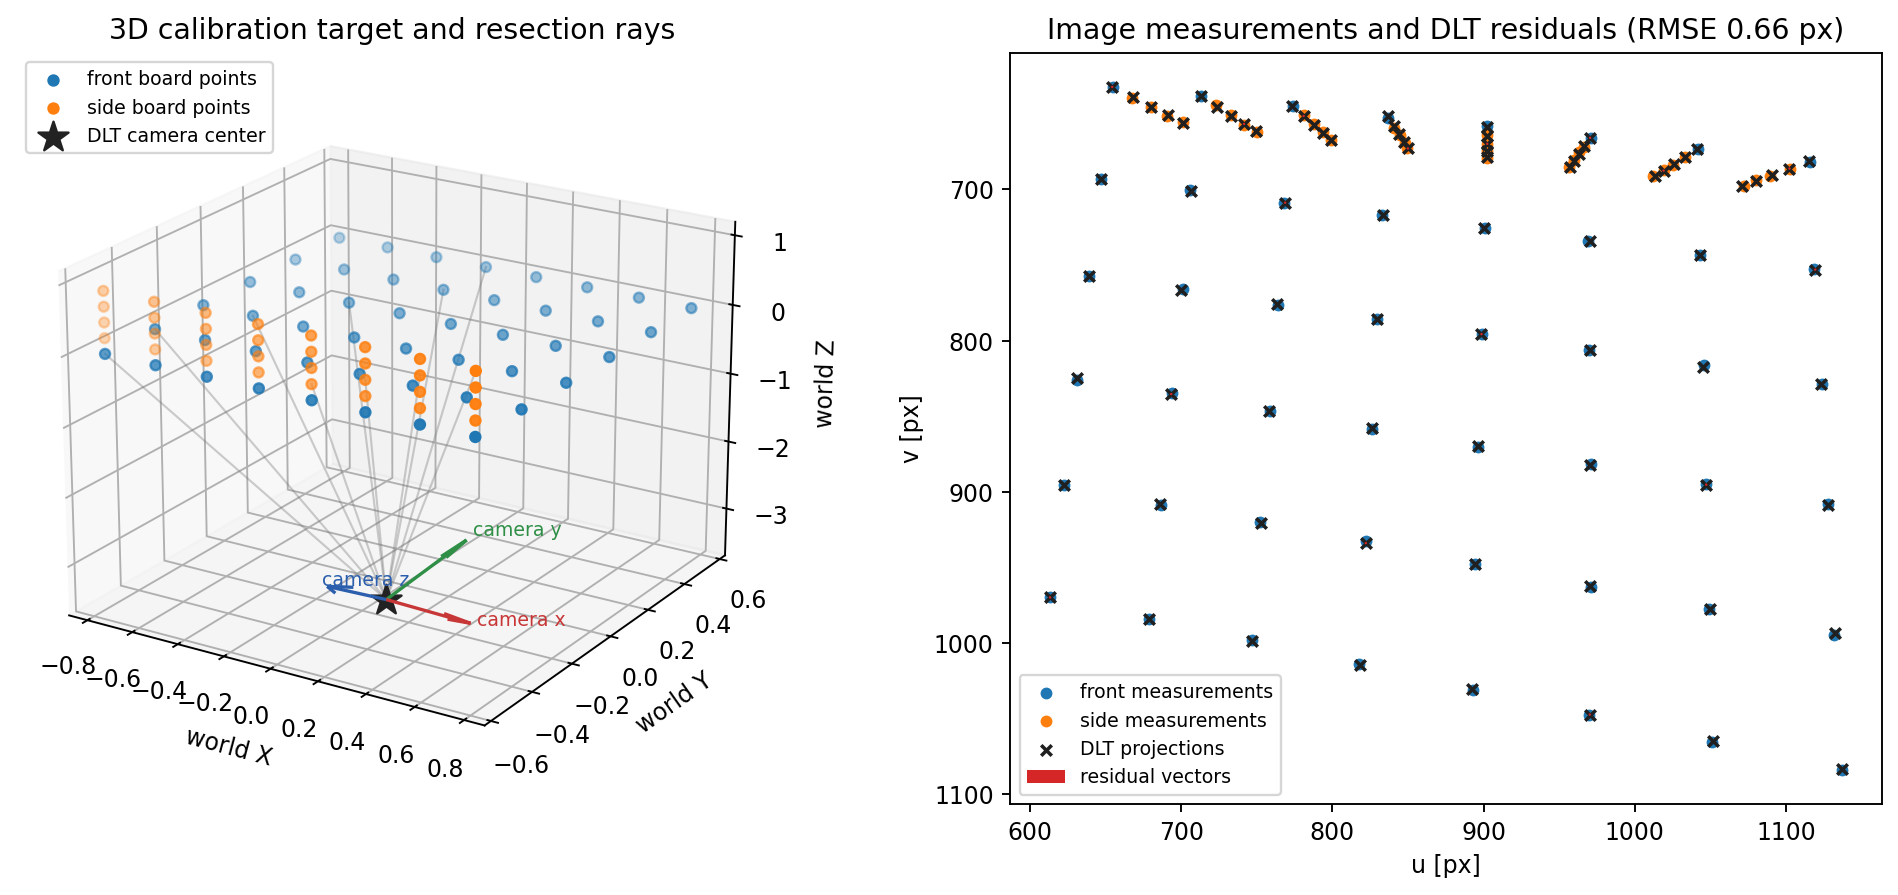

In [5]:
def plot_camera_frame(ax, R, C, scale=0.35):
    C = np.asarray(C).reshape(3)
    axes = R.T @ np.eye(3) * scale
    colors = ["#c83737", "#2f8f46", "#2b5fad"]
    labels = ["camera x", "camera y", "camera z"]
    for vec, color, label in zip(axes.T, colors, labels):
        ax.quiver(C[0], C[1], C[2], vec[0], vec[1], vec[2], color=color, linewidth=1.4)
        ax.text(*(C + vec * 1.08), label, color=color, fontsize=8)

fig = plt.figure(figsize=(12, 5.2))
ax3 = fig.add_subplot(1, 2, 1, projection="3d")
front = plane_id == 0
side = plane_id == 1
ax3.scatter(X_world[front, 0], X_world[front, 1], X_world[front, 2], s=18, color="#1f77b4", label="front board points")
ax3.scatter(X_world[side, 0], X_world[side, 1], X_world[side, 2], s=18, color="#ff7f0e", label="side board points")
C = C_dlt_h[:3]
ax3.scatter([C[0]], [C[1]], [C[2]], marker="*", s=180, color="#222222", label="DLT camera center")
for idx in np.linspace(0, len(X_world) - 1, 10, dtype=int):
    q = X_world[idx]
    ax3.plot([C[0], q[0]], [C[1], q[1]], [C[2], q[2]], color="#777777", alpha=0.36, linewidth=0.9)
plot_camera_frame(ax3, R_true, C, scale=0.42)
ax3.set_title("3D calibration target and resection rays")
ax3.set_xlabel("world X")
ax3.set_ylabel("world Y")
ax3.set_zlabel("world Z")
ax3.legend(loc="upper left", fontsize=8)
ax3.view_init(elev=21, azim=-58)

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(x_measured[front, 0], x_measured[front, 1], s=16, color="#1f77b4", label="front measurements")
ax2.scatter(x_measured[side, 0], x_measured[side, 1], s=16, color="#ff7f0e", label="side measurements")
ax2.scatter(x_dlt[:, 0], x_dlt[:, 1], marker="x", s=20, color="#202020", label="DLT projections")
step = 5
ax2.quiver(x_dlt[::step, 0], x_dlt[::step, 1], residual_dlt[::step, 0], residual_dlt[::step, 1],
           angles="xy", scale_units="xy", scale=1, width=0.003, color="#d62728", label="residual vectors")
ax2.set_title(f"Image measurements and DLT residuals (RMSE {rmse_dlt:.2f} px)")
ax2.set_xlabel("u [px]")
ax2.set_ylabel("v [px]")
ax2.invert_yaxis()
ax2.set_aspect("equal", adjustable="box")
ax2.legend(loc="best", fontsize=8)
fig.tight_layout()

resection_path = save_matplotlib(fig, TOPIC, "figures", "resection-calibration-target.png", dpi=170)
plt.close(fig)
artifact_paths.append(resection_path)
display_artifact(resection_path, width=900)


## 2. DLT Conditioning And Geometric Residuals

The DLT solve minimizes an algebraic residual, so we inspect two things that algebraic error alone hides: the singular spectrum of the design matrix and the pixel residuals after projection. Normalizing image and world coordinates should make the design matrix easier to interpret and should avoid a numerically fragile null vector.


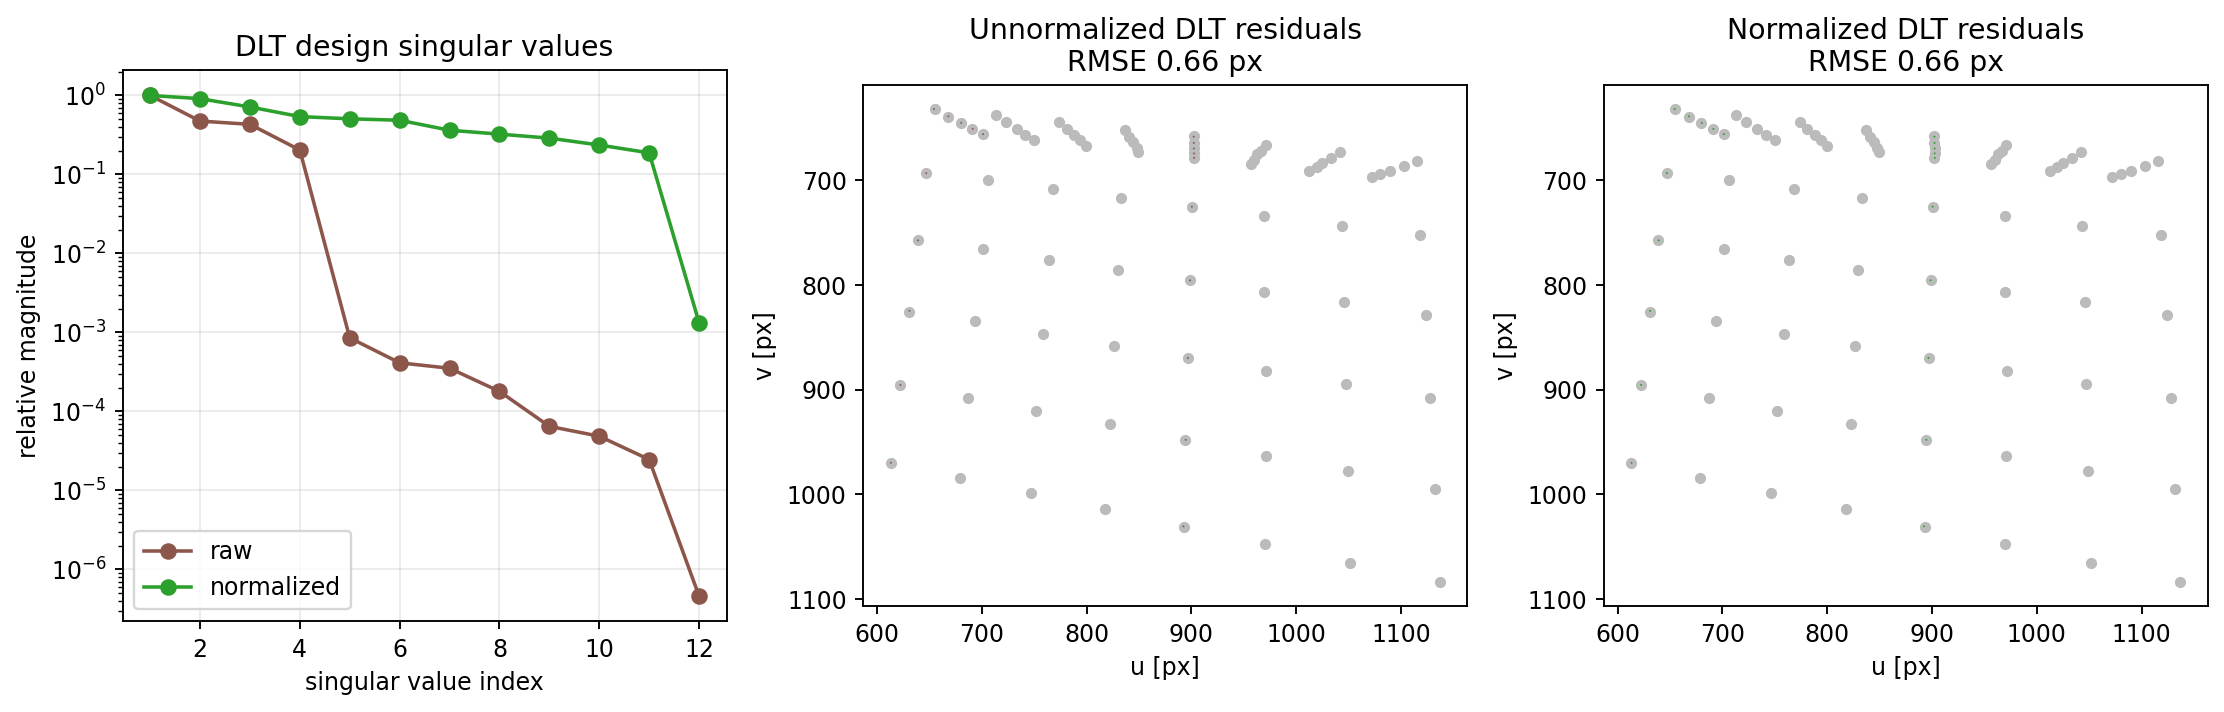

condition ratio raw/normalized: 2.17e+06 / 7.51e+02
null gap raw/normalized: 53.44 / 140.82


In [6]:
condition_raw = float(s_raw[0] / s_raw[-1])
condition_norm = float(s_norm[0] / s_norm[-1])
null_gap_raw = float(s_raw[-2] / s_raw[-1])
null_gap_norm = float(s_norm[-2] / s_norm[-1])

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))
axes[0].semilogy(np.arange(1, len(s_raw) + 1), s_raw / s_raw[0], "o-", color="#8c564b", label="raw")
axes[0].semilogy(np.arange(1, len(s_norm) + 1), s_norm / s_norm[0], "o-", color="#2ca02c", label="normalized")
axes[0].set_title("DLT design singular values")
axes[0].set_xlabel("singular value index")
axes[0].set_ylabel("relative magnitude")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].scatter(x_measured[:, 0], x_measured[:, 1], s=14, color="#bbbbbb", label="measurements")
axes[1].quiver(x_raw[::4, 0], x_raw[::4, 1], residual_raw[::4, 0], residual_raw[::4, 1],
               angles="xy", scale_units="xy", scale=1, width=0.0035, color="#8c564b")
axes[1].set_title(f"Unnormalized DLT residuals\nRMSE {rmse_raw:.2f} px")
axes[1].invert_yaxis()
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("u [px]")
axes[1].set_ylabel("v [px]")

axes[2].scatter(x_measured[:, 0], x_measured[:, 1], s=14, color="#bbbbbb", label="measurements")
axes[2].quiver(x_dlt[::4, 0], x_dlt[::4, 1], residual_dlt[::4, 0], residual_dlt[::4, 1],
               angles="xy", scale_units="xy", scale=1, width=0.0035, color="#2ca02c")
axes[2].set_title(f"Normalized DLT residuals\nRMSE {rmse_dlt:.2f} px")
axes[2].invert_yaxis()
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_xlabel("u [px]")
axes[2].set_ylabel("v [px]")
fig.tight_layout()

conditioning_path = save_matplotlib(fig, TOPIC, "figures", "camera-dlt-conditioning.png", dpi=170)
plt.close(fig)
artifact_paths.append(conditioning_path)
display_artifact(conditioning_path, width=920)

print(f"condition ratio raw/normalized: {condition_raw:.2e} / {condition_norm:.2e}")
print(f"null gap raw/normalized: {null_gap_raw:.2f} / {null_gap_norm:.2f}")


## 3. Radial Distortion Residual Field

A pinhole camera predicts straight-line projective geometry. Radial distortion bends the measurement field before pixels are recorded. Here the synthetic grid is generated with Pillow and the point displacements are generated with OpenCV's distortion model. The arrows show that the mismatch is not random corner noise; it has a radius-dependent direction and grows toward the periphery.


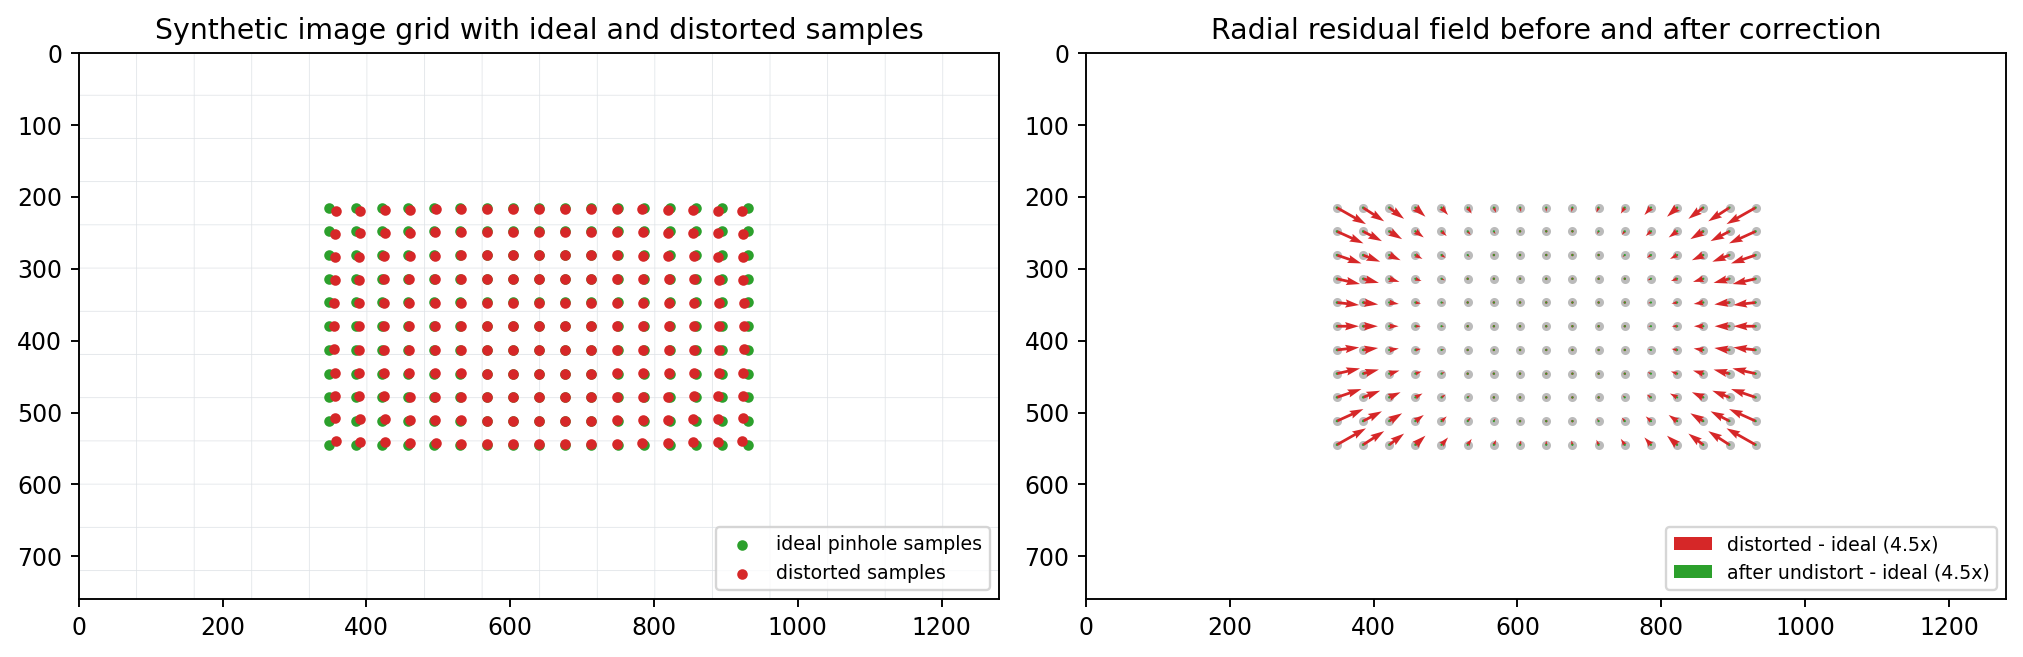

mean distortion residual before correction: 2.910 px
mean distortion residual after correction:  0.000019 px


In [7]:
image_size = (1280, 760)
K_dist = K_true.copy()
dist_coeffs = np.array([-0.24, 0.08, 0.0, 0.0, 0.0], dtype=float)

# Synthetic raster grid: useful because the distortion field is easier to read against straight references.
grid_img = Image.new("RGB", image_size, "white")
draw = ImageDraw.Draw(grid_img)
for u in range(80, image_size[0], 80):
    draw.line([(u, 0), (u, image_size[1])], fill=(222, 226, 230), width=1)
for v in range(60, image_size[1], 60):
    draw.line([(0, v), (image_size[0], v)], fill=(222, 226, 230), width=1)
draw.ellipse((K_dist[0, 2] - 5, K_dist[1, 2] - 5, K_dist[0, 2] + 5, K_dist[1, 2] + 5), fill=(30, 30, 30))

xx, yy = np.meshgrid(np.linspace(-0.95, 0.95, 17), np.linspace(-0.55, 0.55, 11))
rays = np.c_[xx.ravel(), yy.ravel(), np.ones(xx.size)]
ideal_pixels_h = (K_dist @ rays.T).T
ideal_pixels = ideal_pixels_h[:, :2] / ideal_pixels_h[:, 2:]

object_for_cv = np.c_[xx.ravel(), yy.ravel(), np.full(xx.size, 3.0)].astype(np.float32)
distorted_pixels, _ = cv2.projectPoints(object_for_cv, np.zeros(3), np.zeros(3), K_dist, dist_coeffs)
distorted_pixels = distorted_pixels.reshape(-1, 2)
# projectPoints used z=3, so ideal location must use normalized x/z and y/z.
ideal_pixels = (K_dist @ np.c_[object_for_cv[:, 0] / object_for_cv[:, 2], object_for_cv[:, 1] / object_for_cv[:, 2], np.ones(len(object_for_cv))].T).T
ideal_pixels = ideal_pixels[:, :2] / ideal_pixels[:, 2:]

undistorted_norm = cv2.undistortPoints(distorted_pixels.reshape(-1, 1, 2), K_dist, dist_coeffs, P=K_dist).reshape(-1, 2)
distortion_vectors = distorted_pixels - ideal_pixels
corrected_vectors = undistorted_norm - ideal_pixels
mean_distorted_norm = float(np.mean(np.linalg.norm(distortion_vectors, axis=1)))
mean_corrected_norm = float(np.mean(np.linalg.norm(corrected_vectors, axis=1)))
max_distorted_norm = float(np.max(np.linalg.norm(distortion_vectors, axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].imshow(grid_img)
axes[0].scatter(ideal_pixels[:, 0], ideal_pixels[:, 1], s=12, color="#2ca02c", label="ideal pinhole samples")
axes[0].scatter(distorted_pixels[:, 0], distorted_pixels[:, 1], s=12, color="#d62728", label="distorted samples")
axes[0].set_title("Synthetic image grid with ideal and distorted samples")
axes[0].set_xlim(0, image_size[0])
axes[0].set_ylim(image_size[1], 0)
axes[0].legend(loc="lower right", fontsize=8)

axes[1].scatter(ideal_pixels[:, 0], ideal_pixels[:, 1], s=8, color="#bbbbbb")
axes[1].quiver(ideal_pixels[:, 0], ideal_pixels[:, 1], distortion_vectors[:, 0], distortion_vectors[:, 1],
               angles="xy", scale_units="xy", scale=0.22, width=0.003, color="#d62728", label="distorted - ideal (4.5x)")
axes[1].quiver(ideal_pixels[:, 0], ideal_pixels[:, 1], corrected_vectors[:, 0], corrected_vectors[:, 1],
               angles="xy", scale_units="xy", scale=0.22, width=0.0025, color="#2ca02c", label="after undistort - ideal (4.5x)")
axes[1].set_title("Radial residual field before and after correction")
axes[1].set_xlim(0, image_size[0])
axes[1].set_ylim(image_size[1], 0)
axes[1].set_aspect("equal", adjustable="box")
axes[1].legend(loc="lower right", fontsize=8)
fig.tight_layout()

radial_path = save_matplotlib(fig, TOPIC, "figures", "radial-distortion-field.png", dpi=170)
plt.close(fig)
artifact_paths.append(radial_path)
display_artifact(radial_path, width=920)

print(f"mean distortion residual before correction: {mean_distorted_norm:.3f} px")
print(f"mean distortion residual after correction:  {mean_corrected_norm:.6f} px")


## 4. Restricted Camera Parameter Comparison

A full `P` fit has enough freedom to absorb many effects, including some that are not physically meaningful. A restricted model with known intrinsics estimates rotation and translation through `solvePnP`; it uses less freedom but keeps the camera interpretation explicit. The affine fit is included as a deliberate limitation: it is plausible for weak-perspective scenes, but it cannot model this target's perspective depth relief.


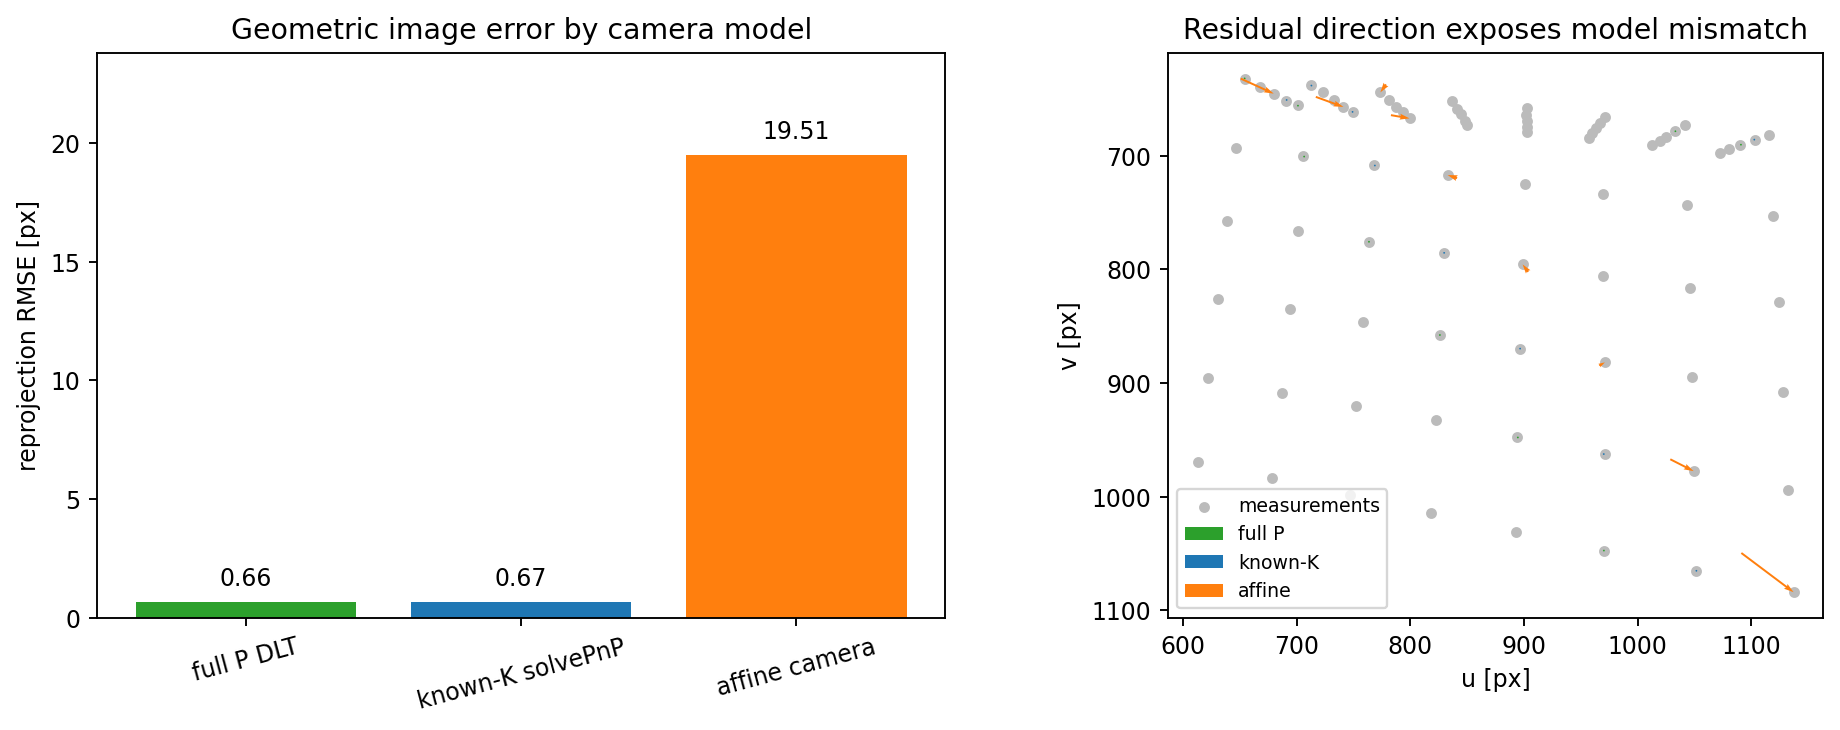

`artifacts/chapter-07/checks/camera-matrix-invariants.json`

In [8]:
success, rvec_pnp, tvec_pnp = cv2.solvePnP(
    X_world.astype(np.float64),
    x_measured.astype(np.float64),
    K_true.astype(np.float64),
    None,
    flags=cv2.SOLVEPNP_ITERATIVE,
)
assert success
R_pnp = cv2.Rodrigues(rvec_pnp)[0]
P_pnp = K_true @ np.hstack([R_pnp, tvec_pnp])
x_pnp, residual_pnp, rmse_pnp = reprojection_residuals(P_pnp, X_world, x_measured)
C_pnp_h = camera_center(P_pnp)

P_aff, x_aff, residual_aff, rmse_aff = affine_camera_fit(X_world, x_measured)

model_names = ["full P DLT", "known-K solvePnP", "affine camera"]
rmse_values = [rmse_dlt, rmse_pnp, rmse_aff]
center_error_dlt = float(np.linalg.norm(C_dlt_h[:3] - C_true_h[:3]))
center_error_pnp = float(np.linalg.norm(C_pnp_h[:3] - C_true_h[:3]))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
colors = ["#2ca02c", "#1f77b4", "#ff7f0e"]
axes[0].bar(model_names, rmse_values, color=colors)
axes[0].set_ylabel("reprojection RMSE [px]")
axes[0].set_title("Geometric image error by camera model")
axes[0].set_ylim(0, max(rmse_values) * 1.22)
axes[0].tick_params(axis="x", rotation=15)
for i, value in enumerate(rmse_values):
    axes[0].text(i, value + 0.025 * max(rmse_values), f"{value:.2f}", ha="center", va="bottom")

axes[1].scatter(x_measured[:, 0], x_measured[:, 1], s=13, color="#bbbbbb", label="measurements")
for pred, res, color, label, offset in [
    (x_dlt, residual_dlt, "#2ca02c", "full P", 0),
    (x_pnp, residual_pnp, "#1f77b4", "known-K", 1),
    (x_aff, residual_aff, "#ff7f0e", "affine", 2),
]:
    sample = slice(offset, None, 9)
    axes[1].quiver(pred[sample, 0], pred[sample, 1], res[sample, 0], res[sample, 1],
                   angles="xy", scale_units="xy", scale=1, width=0.003, color=color, label=label)
axes[1].set_title("Residual direction exposes model mismatch")
axes[1].set_xlabel("u [px]")
axes[1].set_ylabel("v [px]")
axes[1].invert_yaxis()
axes[1].set_aspect("equal", adjustable="box")
axes[1].legend(fontsize=8)
fig.tight_layout()

restricted_path = save_matplotlib(fig, TOPIC, "figures", "restricted-camera-fit.png", dpi=170)
plt.close(fig)
artifact_paths.append(restricted_path)
display_artifact(restricted_path, width=920)

invariants = {
    "source_span": "Chapter 07, printed pages 178-194; PDF pages 196-212",
    "point_count": int(len(X_world)),
    "dlt_design_shape": list(A_norm.shape),
    "P_rank": rank_P,
    "camera_center_nullspace_norm": center_null_residual,
    "true_camera_center": C_true_h[:3].round(8).tolist(),
    "dlt_camera_center": C_dlt_h[:3].round(8).tolist(),
    "solvepnp_camera_center": C_pnp_h[:3].round(8).tolist(),
    "dlt_center_error": center_error_dlt,
    "solvepnp_center_error": center_error_pnp,
    "rmse_pixels": {
        "raw_dlt": rmse_raw,
        "normalized_dlt": rmse_dlt,
        "known_K_solvePnP": rmse_pnp,
        "affine_camera": rmse_aff,
    },
    "dlt_condition_ratio": {
        "raw": condition_raw,
        "normalized": condition_norm,
    },
    "dlt_null_gap": {
        "raw": null_gap_raw,
        "normalized": null_gap_norm,
    },
    "radial_distortion": {
        "mean_residual_before_correction_px": mean_distorted_norm,
        "mean_residual_after_correction_px": mean_corrected_norm,
        "max_residual_before_correction_px": max_distorted_norm,
    },
    "libraries": ["cv2.projectPoints", "cv2.solvePnP", "NumPy/SciPy SVD", "Matplotlib", "Pillow", "SymPy"],
}

invariant_path = save_json(invariants, TOPIC, "checks", "camera-matrix-invariants.json")
artifact_paths.append(invariant_path)
display_artifact(invariant_path)


## Applied Lab

Use this section as a pattern for a real calibration session:

1. Collect at least six non-coplanar 3D-to-2D correspondences, or use multiple target planes.
2. Normalize both 2D and 3D coordinates before DLT, then denormalize the resulting camera matrix.
3. Inspect geometric residual vectors in pixels; do not trust algebraic residuals alone.
4. If intrinsics are known or deliberately constrained, compare a restricted estimate against the full projective fit.
5. If residuals grow radially or curve around the principal point, fit or correct radial distortion before interpreting the remaining error as measurement noise.


## Pitfalls And Failure Modes

- **Planar or nearly planar target:** a full camera matrix can become ambiguous or poorly conditioned unless the scene has enough depth relief.
- **Wrong scale intuition:** `P` is homogeneous, so only ratios and projections are meaningful; the matrix norm is not a physical camera property.
- **Good algebraic residual, bad image residual:** DLT solves `A p = 0`, while calibration quality is judged in pixels.
- **Overfitting with full `P`:** a projective camera may hide wrong intrinsics or lens effects that a restricted physical model exposes.
- **Ignoring distortion:** radial structure in the residual field is model error, not random corner noise.


## Final Sanity Checks

The final cell asserts the notebook contract: artifacts exist, they are nonempty, `P` has rank three, its camera center lies in the nullspace, reprojection error is consistent with injected image noise, and radial correction improves the residual norm.


In [9]:
assert_artifacts(artifact_paths, min_bytes=256)
assert rank_P == 3
assert center_null_residual < 1e-8
assert rmse_dlt < 1.25
assert rmse_pnp < 1.25
assert rmse_aff > rmse_dlt
assert mean_corrected_norm < 0.02 * mean_distorted_norm
for required in [
    BOOK_ROOT / "artifacts" / TOPIC / "figures" / "resection-calibration-target.png",
    BOOK_ROOT / "artifacts" / TOPIC / "figures" / "camera-dlt-conditioning.png",
    BOOK_ROOT / "artifacts" / TOPIC / "figures" / "radial-distortion-field.png",
    BOOK_ROOT / "artifacts" / TOPIC / "figures" / "restricted-camera-fit.png",
    BOOK_ROOT / "artifacts" / TOPIC / "checks" / "camera-matrix-invariants.json",
]:
    assert required.exists() and required.stat().st_size > 256, required

final_sanity = {
    "artifacts": [str(p.relative_to(BOOK_ROOT)) for p in artifact_paths],
    "normalized_dlt_rmse_px": round(rmse_dlt, 4),
    "solvepnp_rmse_px": round(rmse_pnp, 4),
    "affine_rmse_px": round(rmse_aff, 4),
    "camera_center_nullspace_norm": center_null_residual,
    "distortion_improvement_factor": mean_distorted_norm / max(mean_corrected_norm, 1e-12),
}
print(json.dumps(final_sanity, indent=2))


{
  "artifacts": [
    "artifacts\\chapter-07\\figures\\resection-calibration-target.png",
    "artifacts\\chapter-07\\figures\\camera-dlt-conditioning.png",
    "artifacts\\chapter-07\\figures\\radial-distortion-field.png",
    "artifacts\\chapter-07\\figures\\restricted-camera-fit.png",
    "artifacts\\chapter-07\\checks\\camera-matrix-invariants.json"
  ],
  "normalized_dlt_rmse_px": 0.6645,
  "solvepnp_rmse_px": 0.6744,
  "affine_rmse_px": 19.5089,
  "camera_center_nullspace_norm": 4.547475677268469e-13,
  "distortion_improvement_factor": 156682.20570337903
}


## Takeaways

- Resectioning turns 3D-to-2D correspondences into a homogeneous linear system, but the result must be checked geometrically.
- Normalization is not cosmetic; it changes the numerical behavior of the DLT nullspace problem.
- The camera center is an invariant of `P`: it is the right null vector of the projection matrix.
- Restricted models trade flexibility for physical meaning, which is valuable when intrinsics are known or constrained.
- Radial distortion leaves a structured residual field, and correcting it should measurably reduce residual norms before final calibration is judged.
